# Test molt detection model

Runs the trained `KeypointDetection1DModel` on the held-out test split and inspects its predictions.

Current model interface:
- **Multi-channel input**: `X[i]` is `(n_channels, length)` (channel 0 = log volume, channel 1 = log-volume growth rate).
- **Two outputs**: `model.model(x, mask=valid_mask)` returns `(heatmap_logits [B, 4, T], presence_logits [B, 4])`; apply `model.activation` to both.
  - *heatmap* — the *where* of each molt (M1–M4).
  - *presence* — the *whether* of each molt. It is trained against `isnan(keypoint)`, so a **high** value means the molt is **absent**; it is used to gate out spurious peaks.

In [26]:
import pickle
from time import perf_counter

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm import tqdm

from towbintools.deep_learning.architectures import KeypointDetection1DModel
from towbintools.deep_learning.utils.dataset import KeypointDetection1DTrainingDataset

MOLT_NAMES = ["M1", "M2", "M3", "M4"]
FRAME_INTERVAL_MIN = 10  # minutes between frames, for the time axis
device = "cuda" if torch.cuda.is_available() else "cpu"

In [27]:
X = pickle.load(open("X_molt_detection.pickle", "rb"))
y = pickle.load(open("y_gaussian_molt_detection.pickle", "rb"))
keypoints_all = pickle.load(open("keypoints_molt_detection.pickle", "rb"))

y_train, y_test = train_test_split(y, test_size=0.2, random_state=42)
X_raw_train, X_raw_test, keypoints_train, keypoints_test = train_test_split(
    X, keypoints_all, test_size=0.2, random_state=42
)

sample0 = np.asarray(X_raw_test[0])
n_channels = sample0.shape[0] if sample0.ndim > 1 else 1
print(f"{len(X_raw_test)} test samples, {n_channels} input channel(s)")

# resize_method="pad" + valid_mask matches training and feeds the mask the
# presence head needs for its masked temporal pooling.
val_dataset = KeypointDetection1DTrainingDataset(
    inputs=X_raw_test,
    heatmap_targets=y_test,
    index_targets=keypoints_test,
    enforce_divisibility_by=32,
    resize_method="pad",
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=8,
    collate_fn=val_dataset.collate_fn,
)

2249 test samples, 2 input channel(s)


In [28]:
def heatmap_to_keypoints(heatmap, height_threshold=0.25):
    """Highest peak per channel, or NaN if the channel has no peak."""
    peaks = []
    for row in heatmap:
        idx, props = find_peaks(row, height=height_threshold)
        peaks.append(idx[np.argmax(props["peak_heights"])] if len(idx) else np.nan)
    return np.array(peaks, dtype=float)


def gate_by_presence(keypoints, presence, presence_threshold=0.5):
    """Drop molts the presence head calls absent (presence trained on isnan)."""
    keypoints = keypoints.copy()
    keypoints[presence < presence_threshold] = np.nan
    return keypoints


def predict(model, x, mask):
    with torch.no_grad():
        heatmap, presence = model.model(x.to(device), mask=mask.to(device))
        heatmap = model.activation(heatmap).cpu().numpy()
        presence = model.activation(presence).cpu().numpy()
    return heatmap, presence


model_path = "./model_checkpoints/epoch=26-step=3807.ckpt"
model = KeypointDetection1DModel.load_from_checkpoint(model_path).to(device).eval()
print(f"Model loaded! input_channels={dict(model.hparams).get('input_channels')}")

Model loaded! input_channels=2


## Inspect a few predictions

Top panel: predicted heatmaps (solid) vs. ground-truth heatmaps (dotted), with each molt's presence score in the legend.
Bottom panel: the input channels, with **solid** lines = predicted molts and **dashed** = ground-truth molts.

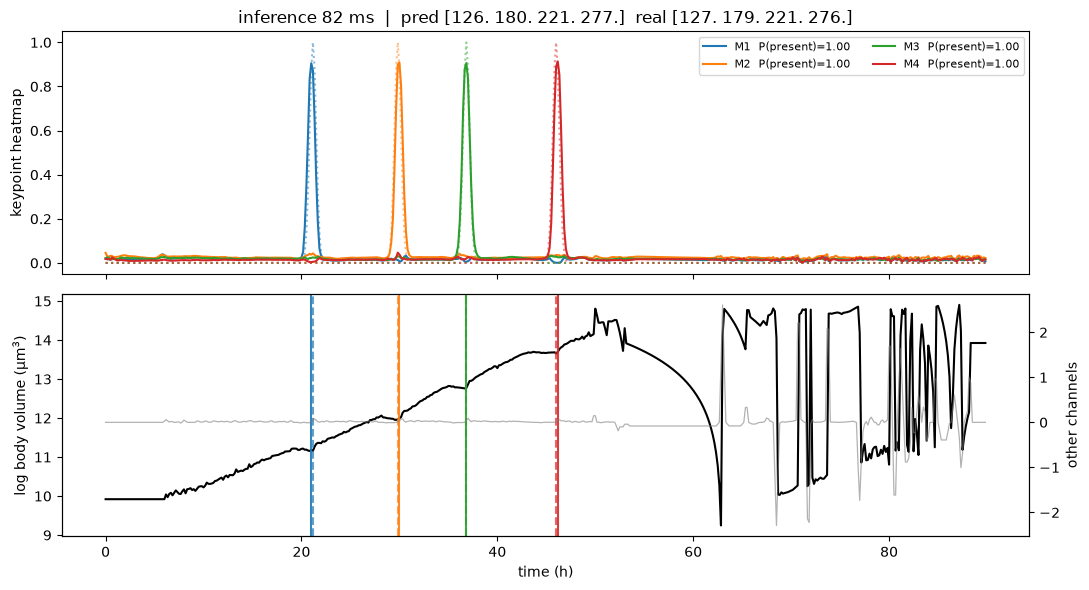

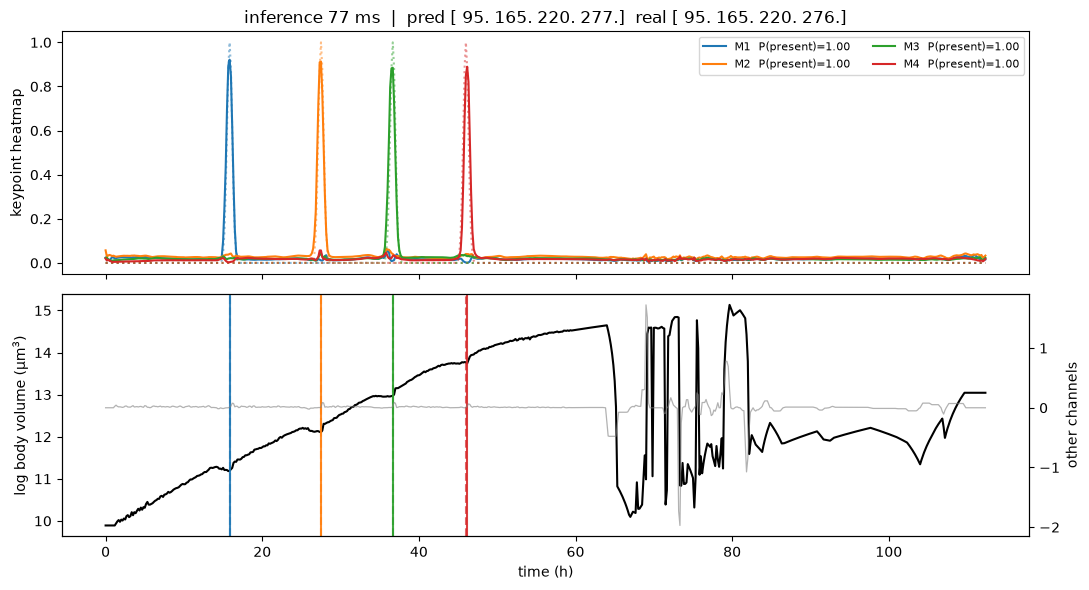

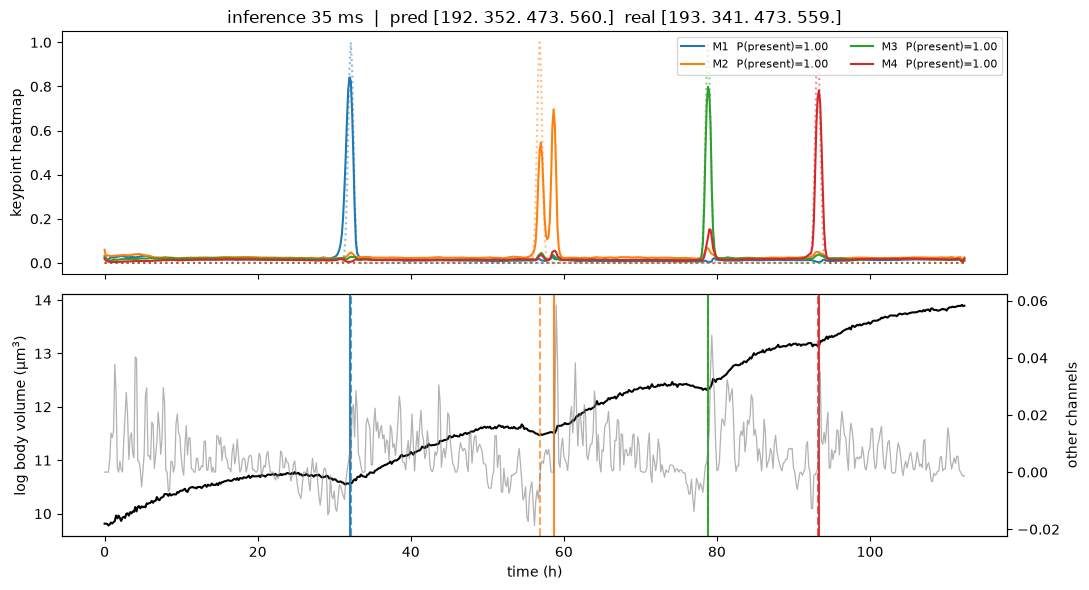

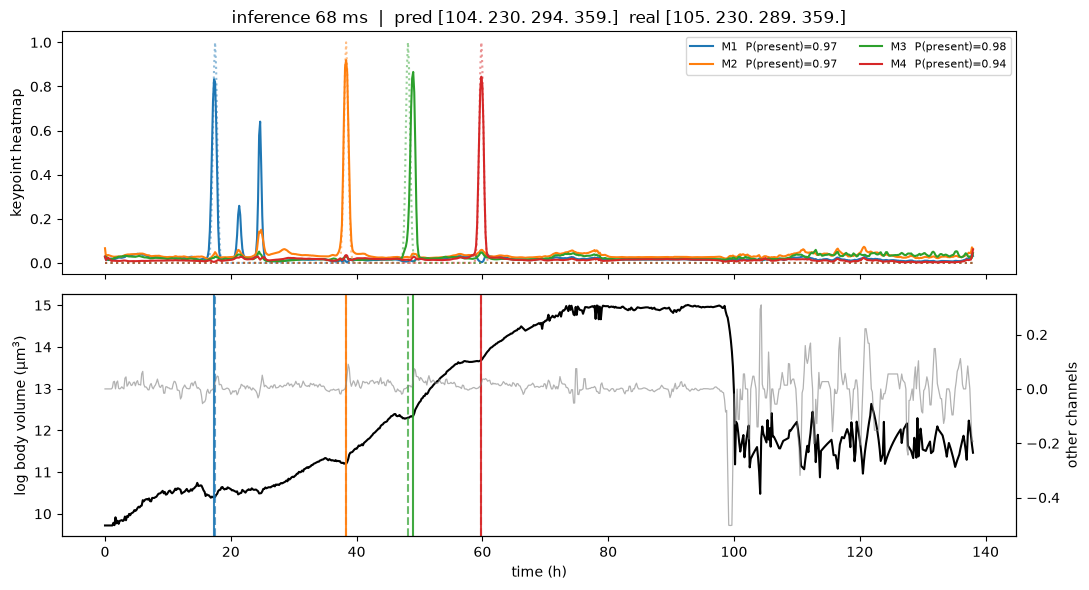

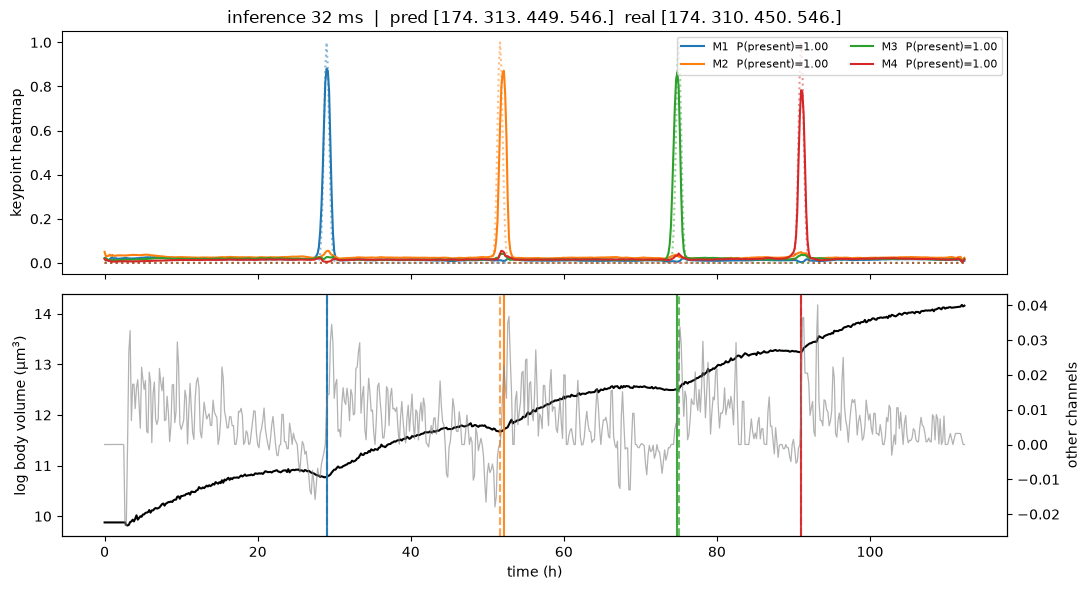

In [33]:
n_show = 5
colors = [f"C{i}" for i in range(len(MOLT_NAMES))]

for shown, batch in enumerate(val_loader):
    if shown >= n_show:
        break
    x, mask, heatmap_target, index_target, presence_target = batch

    start = perf_counter()
    heatmap_hat, presence_hat = predict(model, x, mask)
    elapsed_ms = (perf_counter() - start) * 1e3

    valid = mask[0].cpu().numpy().astype(bool)
    time = np.arange(valid.sum()) * FRAME_INTERVAL_MIN / 60
    xi = x[0].cpu().numpy()[:, valid]                     # [C, T]
    hm_hat = heatmap_hat[0][:, valid]                    # [4, T]
    hm_gt = heatmap_target[0].cpu().numpy()[:, valid]    # [4, T]
    pres_hat = presence_hat[0]                            # [4], high => absent

    pred_molts = gate_by_presence(heatmap_to_keypoints(hm_hat, 0.5), pres_hat)
    real_molts = heatmap_to_keypoints(hm_gt, 0.25)

    fig, (ax_hm, ax_sig) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    for i, name in enumerate(MOLT_NAMES):
        ax_hm.plot(time, hm_hat[i], color=colors[i],
                   label=f"{name}  P(present)={pres_hat[i]:.2f}")
        ax_hm.plot(time, hm_gt[i], color=colors[i], ls=":", alpha=0.5)
    ax_hm.set_ylabel("keypoint heatmap")
    ax_hm.legend(fontsize=8, ncol=2, loc="upper right")
    ax_hm.set_title(f"inference {elapsed_ms:.0f} ms  |  pred {pred_molts}  real {real_molts}")

    ax_sig.plot(time, xi[0], color="black", label="log volume (ch0)")
    if xi.shape[0] > 1:
        ax_other = ax_sig.twinx()
        for c in range(1, xi.shape[0]):
            ax_other.plot(time, xi[c], color="tab:gray", alpha=0.6, lw=0.9)
        ax_other.set_ylabel("other channels")
    for i, frame in enumerate(real_molts):
        if not np.isnan(frame):
            ax_sig.axvline(frame * FRAME_INTERVAL_MIN / 60, color=colors[i], ls="--", alpha=0.7)
    for i, frame in enumerate(pred_molts):
        if not np.isnan(frame):
            ax_sig.axvline(frame * FRAME_INTERVAL_MIN / 60, color=colors[i], ls="-", alpha=0.9)
    ax_sig.set_xlabel("time (h)")
    ax_sig.set_ylabel(r"log body volume $(\mathrm{\mu m^3})$")
    plt.tight_layout()
    plt.show()

## Evaluate over the full test set

Per-molt localization error (in frames) plus miss / over-detection rates. Predictions are gated by the presence head before scoring.

In [30]:
eval_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    collate_fn=val_dataset.collate_fn,
)

bias = 0  # optional constant frame offset applied to predictions
distances = []
n_molts = n_na_molts = miss_detections = over_detections = 0

for batch in tqdm(eval_loader):
    x, mask, heatmap_target, index_target, presence_target = batch
    heatmap_hat, presence_hat = predict(model, x, mask)
    heatmap_target = heatmap_target.cpu().numpy()
    mask_np = mask.cpu().numpy().astype(bool)

    for b in range(heatmap_hat.shape[0]):
        valid = mask_np[b]
        pred = gate_by_presence(
            heatmap_to_keypoints(heatmap_hat[b][:, valid], 0.5), presence_hat[b]
        ) + bias
        real = heatmap_to_keypoints(heatmap_target[b][:, valid], 0.25)

        distances.append(np.abs(pred - real))
        n_molts += np.sum(~np.isnan(real))
        n_na_molts += np.sum(np.isnan(real))
        miss_detections += np.sum(np.isnan(pred) & ~np.isnan(real))
        over_detections += np.sum(~np.isnan(pred) & np.isnan(real))

distances = np.stack([d for d in distances if d.shape == (len(MOLT_NAMES),)])
print(f"{len(distances)} samples scored")

  0%|          | 0/36 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:10<00:00,  3.32it/s]

2249 samples scored


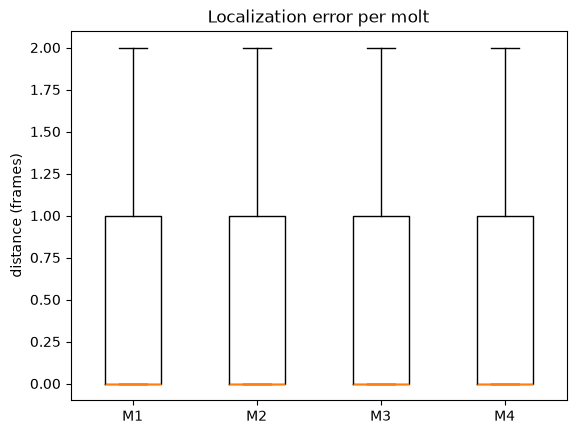

M1: mean=0.87  median=0.00 frames
M2: mean=0.70  median=0.00 frames
M3: mean=1.00  median=0.00 frames
M4: mean=0.62  median=0.00 frames

Overall mean distance: 0.80 frames
Miss detection rate: 0.025
Over detection rate: 0.037


In [31]:
per_molt = [distances[:, i][~np.isnan(distances[:, i])] for i in range(len(MOLT_NAMES))]

plt.boxplot(per_molt, showfliers=False)
plt.xticks(range(1, len(MOLT_NAMES) + 1), MOLT_NAMES)
plt.ylabel("distance (frames)")
plt.title("Localization error per molt")
plt.show()

for i, name in enumerate(MOLT_NAMES):
    print(f"{name}: mean={np.mean(per_molt[i]):.2f}  median={np.median(per_molt[i]):.2f} frames")
print(f"\nOverall mean distance: {np.nanmean(distances):.2f} frames")
print(f"Miss detection rate: {miss_detections / n_molts:.3f}")
print(f"Over detection rate: {over_detections / n_na_molts:.3f}")

## Utility: shrink a checkpoint for deployment

In [34]:
import torch
import os

def create_lightweight_checkpoint(input_path, output_path):
    """
    Load existing PyTorch Lightning checkpoint and save a lightweight version
    """
    # Load the full checkpoint
    print(f"Loading checkpoint from: {input_path}")
    checkpoint = torch.load(input_path, map_location='cpu', weights_only=False)
    
    # Display original file size
    original_size = os.path.getsize(input_path) / (1024 * 1024)  # MB
    print(f"Original file size: {original_size:.2f} MB")
    
    # Create lightweight checkpoint with only essential information
    lightweight_checkpoint = {
        'state_dict': checkpoint['state_dict'],
        'hyper_parameters': checkpoint.get('hyper_parameters', {}),
    }
    
    # Optionally keep other useful metadata
    optional_keys = ['epoch', 'global_step', 'pytorch-lightning_version']
    for key in optional_keys:
        if key in checkpoint:
            lightweight_checkpoint[key] = checkpoint[key]
    
    # Save the lightweight version
    torch.save(lightweight_checkpoint, output_path)
    
    # Display new file size and savings
    new_size = os.path.getsize(output_path) / (1024 * 1024)  # MB
    savings = ((original_size - new_size) / original_size) * 100
    
    print(f"Lightweight file size: {new_size:.2f} MB")
    print(f"Space saved: {savings:.1f}%")
    
    # Show what was removed
    removed_keys = set(checkpoint.keys()) - set(lightweight_checkpoint.keys())
    if removed_keys:
        print(f"Removed keys: {removed_keys}")
    
    return lightweight_checkpoint

# Usage
input_checkpoint = "./model_checkpoints/epoch=26-step=3807.ckpt"
output_checkpoint = "/home/spsalmon/towbintools_pipeline/models/molt_detection_model.ckpt"

lightweight_model = create_lightweight_checkpoint(input_checkpoint, output_checkpoint)

Loading checkpoint from: ./model_checkpoints/epoch=26-step=3807.ckpt
Original file size: 100.44 MB
Lightweight file size: 25.14 MB
Space saved: 75.0%
Removed keys: {'callbacks', 'loops', 'optimizer_states', 'hparams_name', 'lr_schedulers'}
